In [1]:
import numpy as np
import astropy.io.fits as fits
import matplotlib.pyplot as plt
import lightweaver as lw 

In [2]:
filename = '/dat/milic/SUSI_modeling/atm_extended_ssd_angle_80_synth_full_degraded.fits'
spectrum_ssd = fits.open(filename)[0].data
ll = fits.open(filename)[1].data
print(ll)

[392.68881157 392.69081105 392.69281053 ... 394.68429114 394.68629062
 394.6882901 ]


In [3]:
filename = '/dat/milic/SUSI_modeling/atm_extended_en_angle_80_synth_full_degraded.fits'
spectrum_en = fits.open(filename)[0].data
ll = fits.open(filename)[1].data
print(ll)

[392.68881157 392.69081105 392.69281053 ... 394.68429114 394.68629062
 394.6882901 ]


In [4]:
# Air<->vacuum conversion: use the single canonical implementation from calc_op_em
# instead of a local copy. The previous local version used sigma = 1e4/lambda with
# lambda in nm, but that formula needs Angstrom, so it under-shifted ~10x (0.014 nm
# instead of the correct 0.111 nm at Ca II K) -- which offset the synthetic line from
# the observed (air) scale by ~0.1 nm. calc_op_em.vac_to_air is nm-native and correct.
# from calc_op_em import vac_to_air, air_to_vac

# Neither, I will use ones from lw
#ll_air = lw.vac_to_air(ll)

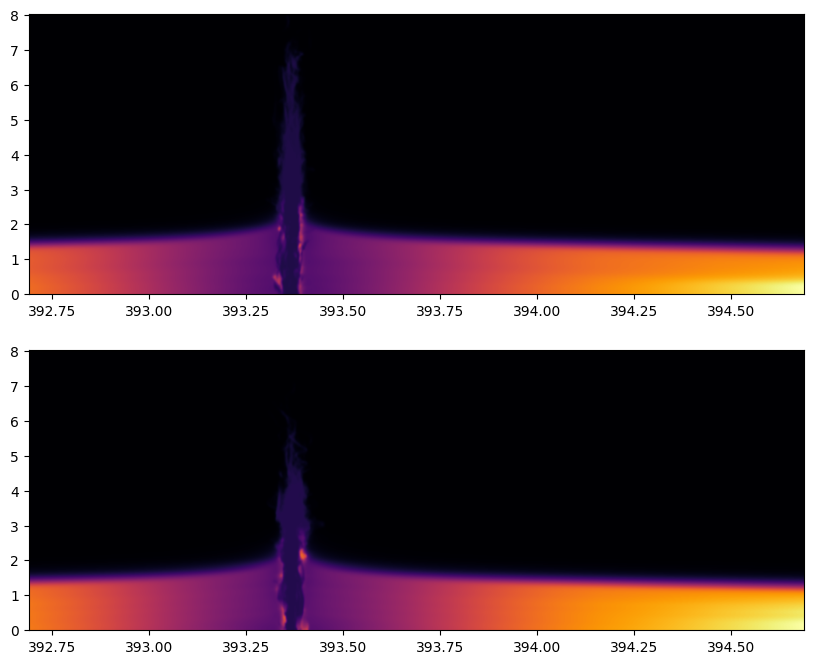

In [5]:
plt.figure(figsize=(10,8))
plt.subplot(211)
plt.imshow(spectrum_ssd[0,:,:],cmap='inferno',origin='lower', extent=[ll[0], ll[-1], 0, spectrum_ssd.shape[1]*0.02], aspect='auto')
plt.subplot(212)
plt.imshow(spectrum_en[0,:,:],cmap='inferno',origin='lower', extent=[ll[0], ll[-1], 0, spectrum_en.shape[1]*0.02], aspect='auto')

In [6]:
# Now create filtergraph by integrating over the wavelength axis, but only the points 0.1 nm around the core of the line:
ll0 = 393.36
filtergraph_ssd = np.sum(spectrum_ssd[:, :, (ll - ll0 > -0.05) & (ll - ll0 < 0.05)], axis=2)
filtergraph_en = np.sum(spectrum_en[:, :, (ll - ll0 > -0.05) & (ll - ll0 < 0.05)], axis=2)
print(filtergraph_ssd.shape)
print(filtergraph_en.shape)

(1024, 401)
(1024, 401)


limb is approximately at z =  70


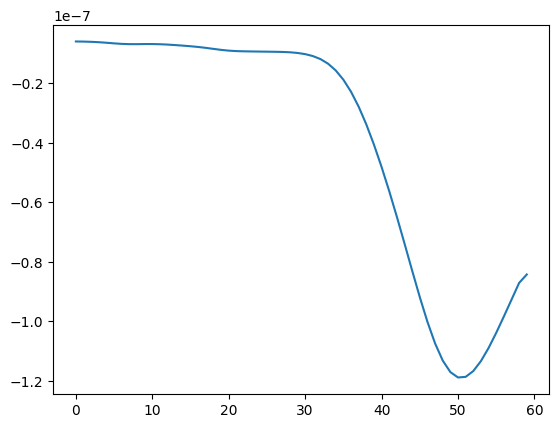

In [7]:
# Create a CLV continuum from the synthetic spectra by averaging over the wavelength axis far from the line core.
continuum_ssd = np.mean(spectrum_ssd[:, :, (ll - ll0 < -0.1) | (ll - ll0 > 0.1)], axis=2)
# and then again integrate over x: 
continuum_ssd_x = np.sum(continuum_ssd, axis=0)

# Plot so that we can find the limb: 
plt.plot(np.gradient(continuum_ssd_x[20:80]))
z_limb = np.argmax(np.abs(np.gradient(continuum_ssd_x[20:80]))) + 20
print("limb is approximately at z = ", z_limb)

In [8]:
x = np.arange(spectrum_ssd.shape[0]) * 0.024 * np.sin(np.radians(80))
z = (np.arange(spectrum_ssd.shape[1])-z_limb) * 0.02 

In [9]:
# Change the font size real quick
plt.rcParams.update({'font.size': 15})

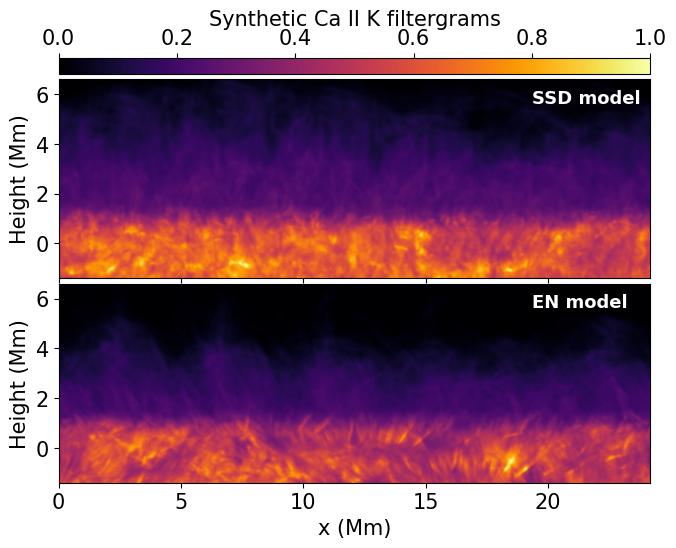

In [10]:
# Stacked filtergrams with a shared colorbar on top (compact half-page style)

#scaling
scaling_curve = 1.0#continuum_ssd_x[None,:] + 2E-1 * np.max(continuum_ssd_x)
filtergraph_ssd_scaled = filtergraph_ssd / scaling_curve
filtergraph_en_scaled = filtergraph_en / scaling_curve

ssd_norm = filtergraph_ssd_scaled.T / np.nanmax(filtergraph_ssd_scaled)
en_norm = filtergraph_en_scaled.T / np.nanmax(filtergraph_en_scaled)

fig = plt.figure(figsize=(6.8, 5.0))
gs = fig.add_gridspec(nrows=3, ncols=1, height_ratios=[0.08, 1, 1], hspace=0.04)

ax_cbar = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[1, 0])
ax2 = fig.add_subplot(gs[2, 0], sharex=ax1, sharey=ax1)

extent = [x[0], x[-1], z[0], z[-1]]
im1 = ax1.imshow(ssd_norm, origin='lower', cmap='inferno', extent=extent, aspect='auto', vmin=0, vmax=1, rasterized=True)
im2 = ax2.imshow(en_norm, origin='lower', cmap='inferno', extent=extent, aspect='auto', vmin=0, vmax=1, rasterized=True)

ax1.text(0.8, 0.95, "SSD model", transform=ax1.transAxes, va='top', ha='left', color='white', fontsize=13, fontweight='bold', bbox=dict(boxstyle='round,pad=0.2', facecolor='black', alpha=0.35, edgecolor='none'))
ax2.text(0.8, 0.95, "EN model", transform=ax2.transAxes, va='top', ha='left', color='white', fontsize=13, fontweight='bold', bbox=dict(boxstyle='round,pad=0.2', facecolor='black', alpha=0.35, edgecolor='none'))

ax1.set_ylabel("Height (Mm)")
ax2.set_ylabel("Height (Mm)")
ax2.set_xlabel("x (Mm)")
ax1.tick_params(labelbottom=False)

cbar = fig.colorbar(im1, cax=ax_cbar, orientation='horizontal')
cbar.set_label("Synthetic Ca II K filtergrams", labelpad=2)
ax_cbar.xaxis.set_ticks_position('top')
ax_cbar.xaxis.set_label_position('top')

fig.subplots_adjust(left=0.11, right=0.98, bottom=0.10, top=0.95)
plt.savefig("figs/filtergrams_stacked_joint_cbar.png", dpi=300, bbox_inches='tight')
plt.savefig("figs/filtergrams_stacked_joint_cbar.pdf", dpi=300, bbox_inches='tight')
plt.show()

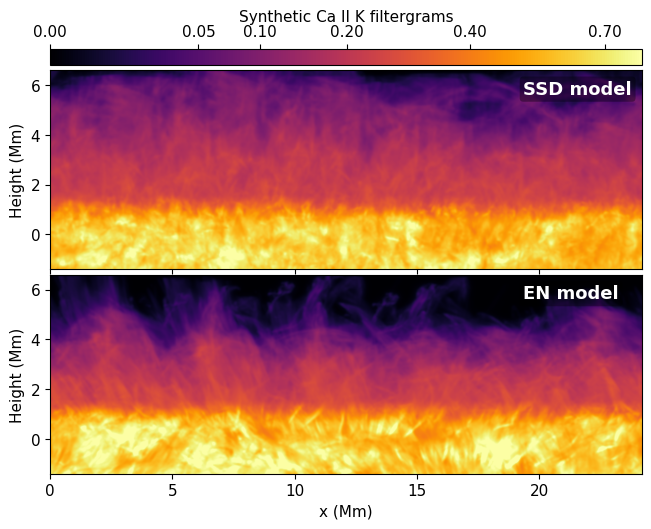

In [11]:
# Same figure as above, but with a non-linear color stretch to emphasize the
# off-limb spicular canopy. Under a linear 0->1 scale the tall faint fibrils sit
# in the bottom ~10-35% of the colormap (near-black); a sqrt stretch expands that
# low end. Changes vs. the cell above:
#   (1) sqrt stretch (PowerNorm gamma=0.5) instead of vmin=0,vmax=1
#   (2) one COMMON normalization for both panels -> SSD and EN stay comparable
#   (3) vmax clipped to the 99.5th percentile so the bright limb strip stops
#       pinning the top of the range.
from matplotlib.colors import PowerNorm, AsinhNorm
plt.rcParams.update({'font.size': 11})

filtergraph_ssd_scaled = filtergraph_ssd / scaling_curve
filtergraph_en_scaled  = filtergraph_en  / scaling_curve

norm_factor = np.nanmax(filtergraph_ssd_scaled)          # common reference for both
ssd_norm = (filtergraph_ssd_scaled / norm_factor).T
en_norm  = (filtergraph_en_scaled  / norm_factor).T

vmax  = np.nanpercentile(filtergraph_ssd_scaled / norm_factor, 99.5)
cnorm = PowerNorm(gamma=0.5, vmin=0, vmax=vmax)          # recommended sqrt stretch
# cnorm = AsinhNorm(linear_width=0.08, vmin=0, vmax=vmax)  # alt: pushes the faint tops harder

fig = plt.figure(figsize=(6.8, 5.0))
gs = fig.add_gridspec(nrows=3, ncols=1, height_ratios=[0.08, 1, 1], hspace=0.04)

ax_cbar = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[1, 0])
ax2 = fig.add_subplot(gs[2, 0], sharex=ax1, sharey=ax1)

extent = [x[0], x[-1], z[0], z[-1]]
im1 = ax1.imshow(ssd_norm, origin='lower', cmap='inferno', extent=extent, aspect='auto', norm=cnorm, rasterized=True)
im2 = ax2.imshow(en_norm, origin='lower', cmap='inferno', extent=extent, aspect='auto', norm=cnorm, rasterized=True)

ax1.text(0.8, 0.95, "SSD model", transform=ax1.transAxes, va='top', ha='left', color='white', fontsize=13, fontweight='bold', bbox=dict(boxstyle='round,pad=0.2', facecolor='black', alpha=0.35, edgecolor='none'))
ax2.text(0.8, 0.95, "EN model", transform=ax2.transAxes, va='top', ha='left', color='white', fontsize=13, fontweight='bold', bbox=dict(boxstyle='round,pad=0.2', facecolor='black', alpha=0.35, edgecolor='none'))

ax1.set_ylabel("Height (Mm)")
ax2.set_ylabel("Height (Mm)")
ax2.set_xlabel("x (Mm)")
ax1.tick_params(labelbottom=False)

cbar = fig.colorbar(im1, cax=ax_cbar, orientation='horizontal', ticks=[0, 0.05, 0.1, 0.2, 0.4, 0.7])
cbar.set_label("Synthetic Ca II K filtergrams", labelpad=2)
ax_cbar.xaxis.set_ticks_position('top')
ax_cbar.xaxis.set_label_position('top')

fig.subplots_adjust(left=0.11, right=0.98, bottom=0.10, top=0.95)
plt.savefig("figs/filtergrams_stacked_joint_cbar_stretched.png", dpi=300, bbox_inches='tight')
plt.savefig("figs/filtergrams_stacked_joint_cbar_stretched.pdf", dpi=300, bbox_inches='tight')
#plt.show()

In [12]:
# Load normalized off-limb spectrum from file
path = '/dat/milic/SUSI_modeling/susi_cube_202407132153_normalized.fits'
cube = fits.open(path)[0].data
ll_obs = fits.open(path)[1].data
limbdistances_obs = fits.open(path)[2].data
velocities_obs = fits.open(path)[3].data

In [13]:
cube.shape

(240, 1556, 1912)

In [14]:
# find where plus minus 50 km/s are in the observed spectrum:
index_vel_minus_50 = np.argmin(np.abs(velocities_obs + 50))
index_vel_plus_50 = np.argmin(np.abs(velocities_obs - 50))
print(f"Index for -50 km/s: {index_vel_minus_50}, wavelength: {ll_obs[index_vel_minus_50]:.3f} nm")
print(f"Index for +50 km/s: {index_vel_plus_50}, wavelength: {ll_obs[index_vel_plus_50]:.3f} nm")

Index for -50 km/s: 475, wavelength: 393.301 nm
Index for +50 km/s: 603, wavelength: 393.432 nm


In [15]:
# and the same in the synthetic air spectrum:
# define the line center as the wavelength corresponding to the line core in the observations:
central_wavelength_obs = ll_obs[np.argmin(np.abs(velocities_obs))]

index_vel_minus_50_synth = np.argmin(np.abs(ll - (central_wavelength_obs * (1 - 50/3E5))))
index_vel_plus_50_synth = np.argmin(np.abs(ll - (central_wavelength_obs * (1 + 50/3E5))))
print(f"Synthetic -50 km/s: index {index_vel_minus_50_synth}, wavelength: {ll[index_vel_minus_50_synth]:.3f} nm")
print(f"Synthetic +50 km/s: index {index_vel_plus_50_synth}, wavelength: {ll[index_vel_plus_50_synth]:.3f} nm")

Synthetic -50 km/s: index 306, wavelength: 393.301 nm
Synthetic +50 km/s: index 372, wavelength: 393.433 nm


In [16]:
# Adjust font size
plt.rcParams.update({'font.size': 14})

In [17]:
# Now find the x coordintes where x = 8 Mm for ssd and 6.5 Mm for en, and plot the spectra at those x coordinates.
x_coord_ssd = 8.0  # Mm
x_coord_en = 6.5  # Mm

# Indices:
index_ssd = np.argmin(np.abs(x - x_coord_ssd))
index_en = np.argmin(np.abs(x - x_coord_en))


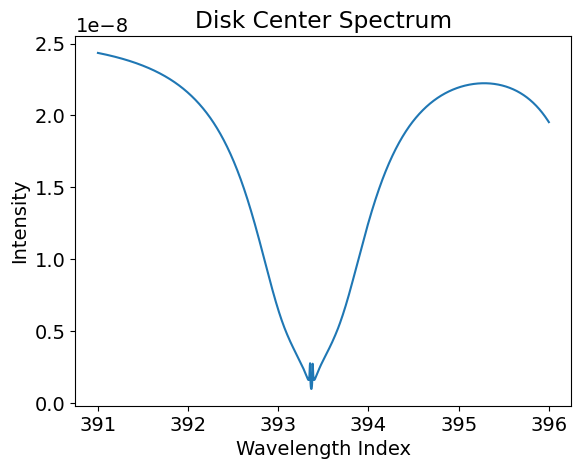

In [18]:
# But before the further plots, load the disk center spectrum and normalize the observations: 
# Let's try to find the maximum intensity in the mean spectrum from lw from the disk center: 
lw_1d = fits.open('disk_center_test.fits')
diskcenter_spectrum = lw_1d[0].data
ll_lw = lw_1d[1].data
plt.plot(ll_lw,diskcenter_spectrum)
plt.xlabel('Wavelength Index')
plt.ylabel('Intensity')
plt.title('Disk Center Spectrum')
plt.show()

In [19]:
# Pick the intensity closest to the 394.72 
target_wavelength = 394.72
closest_index = np.argmin(np.abs(ll_lw - target_wavelength))
closest_intensity = diskcenter_spectrum[closest_index]
closest_wavelength = ll_lw[closest_index]
print(f"Closest wavelength to {target_wavelength} is {closest_wavelength} with intensity {closest_intensity}")

Closest wavelength to 394.72 is 394.72 with intensity 2.10141798321123e-08


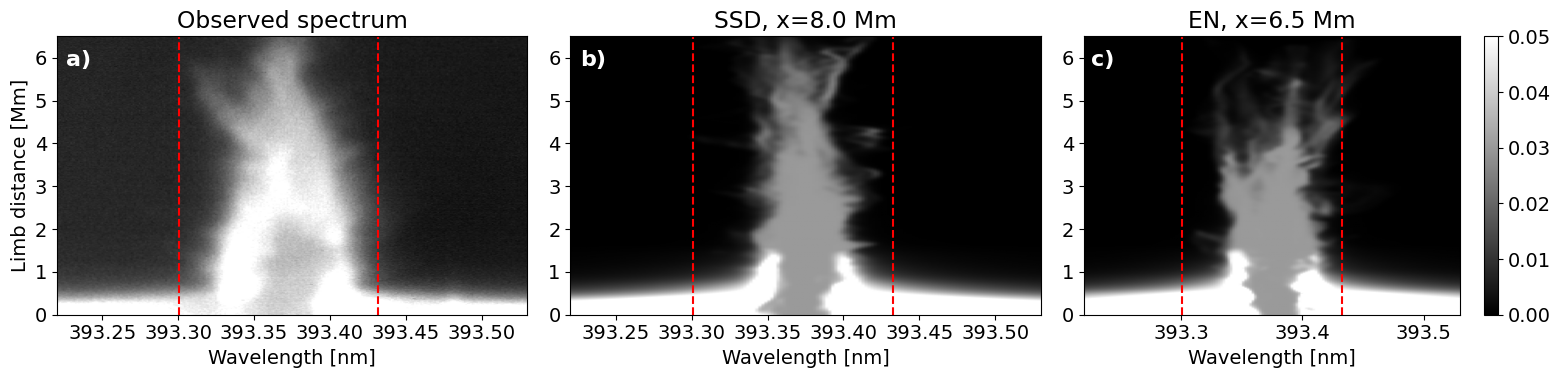

In [20]:
# Show a comparison between the first time instance of the observed spectrum and some example synthetic spectra, without 
# any spatial averaging.

plt.figure(figsize=(16,4))
plt.subplot(131)
plt.imshow(cube[1], origin='lower', extent=[ll_obs[0],ll_obs[-1], limbdistances_obs[0]/1e3, limbdistances_obs[-1]/1e3], aspect='auto', vmin=0.00, vmax=0.05, cmap='gray', rasterized=True)
plt.vlines([ll_obs[index_vel_minus_50], ll_obs[index_vel_plus_50]], 0, 6.5, colors='red', linestyles='dashed')
#plt.colorbar()
plt.xlim(393.22, 393.53)
plt.ylim(0,6.5)
plt.ylabel("Limb distance [Mm]")
plt.xlabel("Wavelength [nm]")
plt.title("Observed spectrum")
# denote panel with a)
plt.text(0.02, 0.95, 'a)', transform=plt.gca().transAxes, fontsize=16, fontweight='bold', va='top', color='white')

plt.subplot(132)
plt.imshow(spectrum_ssd[index_ssd]/closest_intensity, origin='lower', extent=[ll[0]+0.01,ll[-1]+0.01, z[0], z[-1]], aspect='auto', vmin=0.00, vmax=0.05, cmap='gray', rasterized=True)
plt.ylim([0,6.5])
plt.xlim(393.22, 393.53)
plt.vlines([ll[index_vel_minus_50_synth], ll[index_vel_plus_50_synth]], 0, 6.5, colors='red', linestyles='dashed')
#plt.colorbar()
plt.title(f"SSD, x={x_coord_ssd} Mm")
plt.xlabel("Wavelength [nm]")

plt.text(0.02, 0.95, 'b)', transform=plt.gca().transAxes, fontsize=16, fontweight='bold', va='top', color='white')

plt.subplot(133)
plt.imshow(spectrum_en[index_en]/closest_intensity, origin='lower', extent=[ll[0]+0.01,ll[-1]+0.01, z[0], z[-1]], aspect='auto', vmin=0.00, vmax=0.05, cmap='gray', rasterized=True)
plt.ylim([0,6.5])
plt.xlim(393.22, 393.53)
plt.vlines([ll[index_vel_minus_50_synth], ll[index_vel_plus_50_synth]], 0, 6.5, colors='red', linestyles='dashed')
plt.colorbar()
plt.title(f"EN, x={x_coord_en} Mm")
plt.xlabel("Wavelength [nm]")

plt.text(0.02, 0.95, 'c)', transform=plt.gca().transAxes, fontsize=16, fontweight='bold', va='top', color='white')

plt.tight_layout()
plt.savefig("figs/off_limb_slit_detailed_examples.png",bbox_inches='tight', dpi=300)
plt.savefig("figs/off_limb_slit_detailed_examples.pdf",bbox_inches='tight', dpi=300)

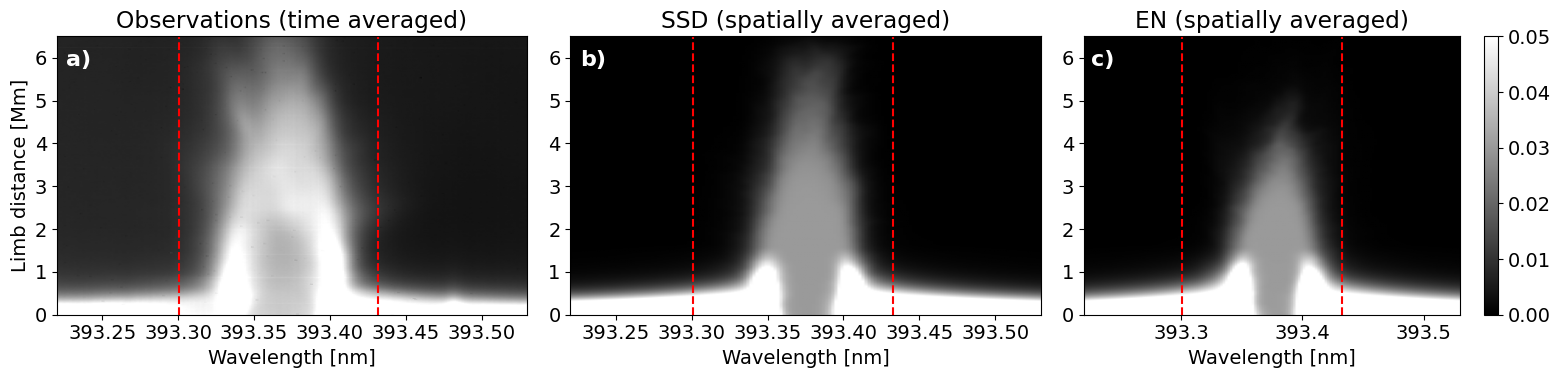

In [21]:
# Then everything the same but averaged over the first axis: 
# Show a comparison between the first time instance of the observed spectrum and some example synthetic spectra, without 
# any spatial averaging.

plt.figure(figsize=(16,4))
plt.subplot(131)
plt.imshow(np.mean(cube, axis=0), origin='lower', extent=[ll_obs[0],ll_obs[-1], limbdistances_obs[0]/1e3, limbdistances_obs[-1]/1e3], aspect='auto', vmin=0.00, vmax=0.05, cmap='gray', rasterized=True)
plt.vlines([ll_obs[index_vel_minus_50], ll_obs[index_vel_plus_50]], 0, 6.5, colors='red', linestyles='dashed')
#plt.colorbar()
plt.xlim(393.22, 393.53)
plt.ylim(0,6.5)
plt.ylabel("Limb distance [Mm]")
plt.xlabel("Wavelength [nm]")
plt.title("Observations (time averaged)")
# denote panel with a)
plt.text(0.02, 0.95, 'a)', transform=plt.gca().transAxes, fontsize=16, fontweight='bold', va='top', color='white')

plt.subplot(132)
plt.imshow(np.mean(spectrum_ssd, axis=0)/closest_intensity, origin='lower', extent=[ll[0]+0.01,ll[-1]+0.01, z[0], z[-1]], aspect='auto', vmin=0.00, vmax=0.05, cmap='gray', rasterized=True)
plt.ylim([0,6.5])
plt.xlim(393.22, 393.53)
plt.vlines([ll[index_vel_minus_50_synth], ll[index_vel_plus_50_synth]], 0, 6.5, colors='red', linestyles='dashed')
#plt.colorbar()
plt.title("SSD (spatially averaged)")
plt.xlabel("Wavelength [nm]")

plt.text(0.02, 0.95, 'b)', transform=plt.gca().transAxes, fontsize=16, fontweight='bold', va='top', color='white')

plt.subplot(133)
plt.imshow(np.mean(spectrum_en, axis=0)/closest_intensity, origin='lower', extent=[ll[0]+0.01,ll[-1]+0.01, z[0], z[-1]], aspect='auto', vmin=0.00, vmax=0.05, cmap='gray', rasterized=True)
plt.ylim([0,6.5])
plt.xlim(393.22, 393.53)
plt.vlines([ll[index_vel_minus_50_synth], ll[index_vel_plus_50_synth]], 0, 6.5, colors='red', linestyles='dashed')
plt.colorbar()
plt.title("EN (spatially averaged)")
plt.xlabel("Wavelength [nm]")

plt.text(0.02, 0.95, 'c)', transform=plt.gca().transAxes, fontsize=16, fontweight='bold', va='top', color='white')

plt.tight_layout()
plt.savefig("figs/off_limb_slit_detailed_examples_avg.png",bbox_inches='tight', dpi=300)
plt.savefig("figs/off_limb_slit_detailed_examples_avg.pdf",bbox_inches='tight', dpi=300)

In [22]:
# Core line width (km/s) for SSD, EN, and observations.
#
# The observed off-limb profiles sit on a broad, ~flat BACKGROUND (scattered /
# stray disk light -- ~13% of the core peak at z=3 Mm) that the pure-emission
# synthetic profiles do not have. A raw second moment over a wide window is
# dominated by that background (v^2 weighting), so it measures the stray light,
# not the line -- and widening the window makes it worse. Instead we:
#   (1) estimate the background per profile as the median in the far wings
#       (v_bg[0] <= |v| <= v_bg[1]) and subtract it  (=> ~0 for the synthetics),
#   (2) take the second-moment width over the line CORE only (|v| <= v_core).
# Applied identically to obs and sim, so the comparison is like-for-like.

c_kms = 299792.458
lam0 = 393.36

v_core = 50.0            # km/s: moment taken over |v| <= v_core (line core)
v_bg   = (80.0, 150.0)   # km/s: |v| band used to estimate the flat background

# Full velocity axes (no pre-masking; core_width selects core vs background bands)
vel_syn = c_kms * (ll - lam0) / lam0
vel_obs = c_kms * (ll_obs - lam0) / lam0


def core_width(cube_lambda_last, vel_axis, v_core=v_core, v_bg=v_bg):
    """
    Background-subtracted, core-restricted second-moment width (km/s).

    cube_lambda_last: array (..., n_lambda), wavelength/velocity last
    vel_axis:         array (n_lambda,) in km/s, relative to lam0
    returns:          width with shape cube_lambda_last.shape[:-1]

    Background = median intensity over v_bg[0] <= |v| <= v_bg[1] (per profile),
    subtracted before the moment; the moment uses only |v| <= v_core, with
    negatives clipped to zero.
    """
    v = np.asarray(vel_axis)
    bg_mask   = (np.abs(v) >= v_bg[0]) & (np.abs(v) <= v_bg[1])
    core_mask = np.abs(v) <= v_core

    bg = np.nanmedian(cube_lambda_last[..., bg_mask], axis=-1, keepdims=True)
    I  = np.clip(cube_lambda_last[..., core_mask] - bg, 0.0, None)

    vc = v[core_mask]
    vv = vc.reshape((1,) * (I.ndim - 1) + (vc.size,))
    wsum = np.sum(I, axis=-1)
    with np.errstate(divide="ignore", invalid="ignore"):
        v_mean = np.sum(I * vv, axis=-1) / wsum
        m2 = np.sum(I * (vv - v_mean[..., None]) ** 2, axis=-1) / wsum
    return np.sqrt(m2)


# Synthetic per-pixel maps (panels a & b)
width_ssd = core_width(spectrum_ssd, vel_syn)
width_en  = core_width(spectrum_en,  vel_syn)

# Observation per-pixel map (time, z)
width_obs = core_width(cube, vel_obs)

# z-profiles (panel c): width of the *averaged* spectrum (sims x-avg, obs time-avg).
# Averaging the spectra first blends the Doppler-shifted components into the
# composite profile an integrated observation actually records.
width_ssd_z = core_width(np.nanmean(spectrum_ssd, axis=0), vel_syn)  # (z,)
width_en_z  = core_width(np.nanmean(spectrum_en,  axis=0), vel_syn)  # (z,)
width_obs_z = core_width(np.nanmean(cube, axis=0), vel_obs)          # (z,)

# z coordinate for observations (Mm)
z_obs = limbdistances_obs / 1e3

print("width_ssd:", width_ssd.shape, np.nanmin(width_ssd), np.nanmax(width_ssd))
print("width_en: ", width_en.shape,  np.nanmin(width_en),  np.nanmax(width_en))
print("width_obs:", width_obs.shape, np.nanmin(width_obs), np.nanmax(width_obs))
print("z-profile (core, bg-subtracted) ssd/en/obs max:",
      np.nanmax(width_ssd_z), np.nanmax(width_en_z), np.nanmax(width_obs_z))

width_ssd: (1024, 401) 0.0 42.93169448114691
width_en:  (1024, 401) 0.0 41.751973496582096
width_obs: (240, 1556) 0.0 37.85842405933186
z-profile (core, bg-subtracted) ssd/en/obs max: 32.10695075113026 31.22474629347959 30.58572545040497


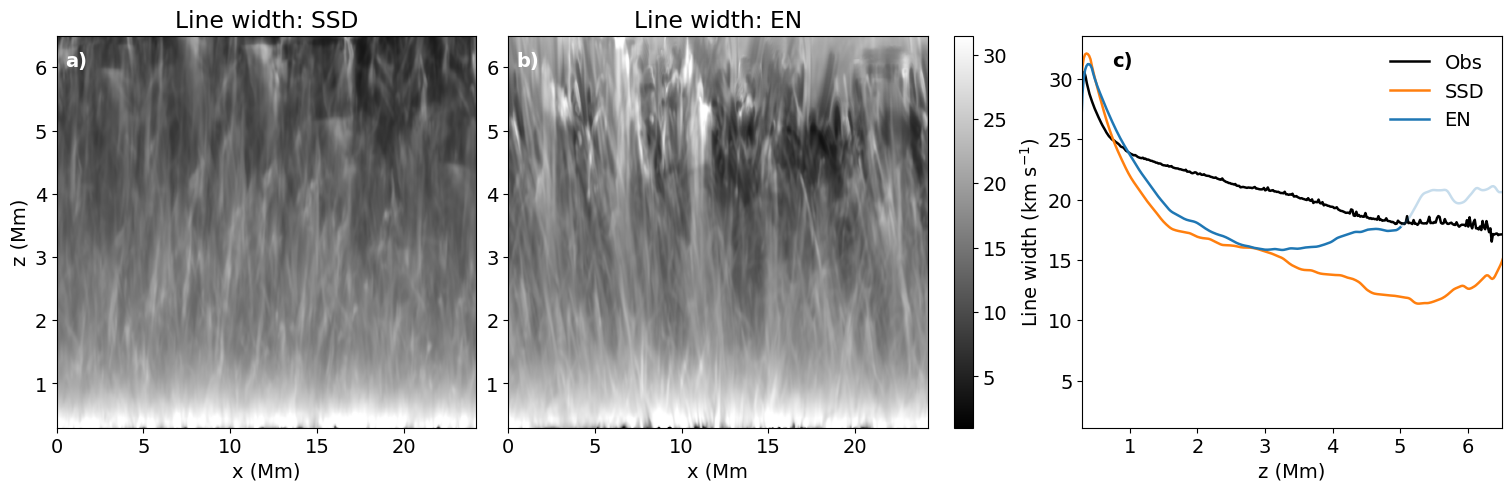

In [31]:
# 1x3 figure:
# (a) SSD core-width map
# (b) EN core-width map
# (c) core width of the AVERAGE spectrum vs z (obs time-avg, sims x-avg)

fig, ax = plt.subplots(1, 3, figsize=(15, 4.8), constrained_layout=True)

# Common color scaling for the two maps (robust 1-99 percentiles).
vmin, vmax = np.nanpercentile(
    np.concatenate([width_ssd.ravel(), width_en.ravel()]), [1, 99]
)

extent_syn = [x[0], x[-1], z[0], z[-1]]

im_a = ax[0].imshow(
    width_ssd.T, origin="lower", extent=extent_syn, aspect="auto",
    cmap="gray", vmin=vmin, vmax=vmax, rasterized=True
)
ax[0].set_title("Line width: SSD")
ax[0].set_xlabel("x (Mm)")
ax[0].set_ylim(0.3, 6.5)
ax[0].set_ylabel("z (Mm)")
ax[0].text(0.02, 0.96, "a)", transform=ax[0].transAxes, va="top", ha="left",
           color="white", fontweight="bold")


im_b = ax[1].imshow(
    width_en.T, origin="lower", extent=extent_syn, aspect="auto",
    cmap="gray", vmin=vmin, vmax=vmax, alpha=alpha_en, rasterized=True
)
ax[1].set_title("Line width: EN")
ax[1].set_xlabel("x (Mm")
#ax[1].set_ylabel("z (Mm)")
ax[1].set_ylim(0.3, 6.5)
ax[1].text(0.02, 0.96, "b)", transform=ax[1].transAxes, va="top", ha="left",
           color="white", fontweight="bold")

cbar = fig.colorbar(im_b, ax=ax[:2], fraction=0.046, pad=0.03)
#cbar.set_label("Core line width (km s$^{-1}$)")

# Panel (c): core width of the averaged spectrum vs z (computed in the previous cell)
mask_obs_z = (z_obs >= 0.0) & (z_obs <= 6.5)
mask_syn_z_low = (z >= 0.0) & (z <= 5.0)
mask_syn_z_high = (z > 5.0) & (z <= 6.5)

ax[2].plot(z_obs[mask_obs_z], width_obs_z[mask_obs_z], color="k", lw=1.8, label="Obs")
ax[2].plot(z, width_ssd_z, color="tab:orange", lw=1.8, label="SSD")
ax[2].plot(z[mask_syn_z_low], width_en_z[mask_syn_z_low], color="tab:blue", lw=1.8, label="EN")
ax[2].plot(z[mask_syn_z_high], width_en_z[mask_syn_z_high], color="tab:blue", lw=1.8, alpha=0.25)

ax[2].set_xlabel("z (Mm)")
ax[2].set_ylabel("Line width (km s$^{-1}$)")
ax[2].set_xlim(0.3, 6.5)
ax[2].legend(frameon=False, fontsize=14)
#ax[2].set_title("Average spectra core width vs z")
ax[2].text(0.07, 0.96, "c)", transform=ax[2].transAxes, va="top", ha="left",
           fontweight="bold")

plt.savefig("figs/second_moment_maps_and_z_profiles.png", dpi=300, bbox_inches="tight")
plt.savefig("figs/second_moment_maps_and_z_profiles.pdf", dpi=300, bbox_inches="tight")
plt.show()

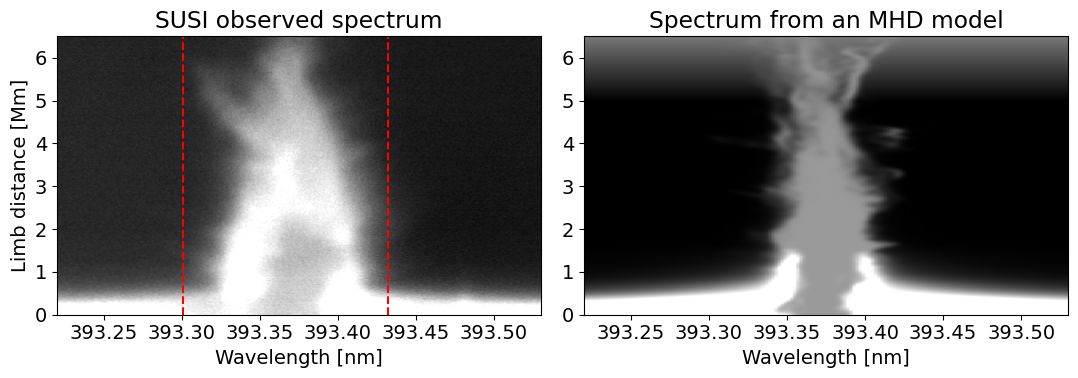

In [27]:
# One more like the one above, but this time just with first two. 
# Show a comparison between the first time instance of the observed spectrum and some example synthetic spectra, without 
# any spatial averaging.

plt.figure(figsize=(11,4))
plt.subplot(121)
plt.imshow(cube[1], origin='lower', extent=[ll_obs[0],ll_obs[-1], limbdistances_obs[0]/1e3, limbdistances_obs[-1]/1e3], aspect='auto', vmin=0.00, vmax=0.05, cmap='gray', rasterized=True)
plt.vlines([ll_obs[index_vel_minus_50], ll_obs[index_vel_plus_50]], 0, 6.5, colors='red', linestyles='dashed')
#plt.colorbar()
plt.xlim(393.22, 393.53)
plt.ylim(0,6.5)
plt.ylabel("Limb distance [Mm]")
plt.xlabel("Wavelength [nm]")
plt.title("SUSI observed spectrum")
# denote panel with a)
#plt.text(0.02, 0.95, 'a)', transform=plt.gca().transAxes, fontsize=16, fontweight='bold', va='top', color='white')

plt.subplot(122)
plt.imshow(spectrum_ssd[index_ssd]/closest_intensity, origin='lower', extent=[ll[0]+0.01,ll[-1]+0.01, z[0], z[-1]], aspect='auto', vmin=0.00, vmax=0.05, cmap='gray', rasterized=True)
plt.ylim([0,6.5])
plt.xlim(393.22, 393.53)
plt.vlines([ll[index_vel_minus_50], ll[index_vel_plus_50]], 0, 6.5, colors='red', linestyles='dashed')
#plt.colorbar()
plt.title(f"Spectrum from an MHD model")
plt.xlabel("Wavelength [nm]")

#plt.text(0.02, 0.95, 'b)', transform=plt.gca().transAxes, fontsize=16, fontweight='bold', va='top', color='white')

plt.tight_layout()
plt.savefig("figs/off_limb_slit_2panel_forSAC.png",bbox_inches='tight', dpi=300)
plt.savefig("figs/off_limb_slit_2panel_forSAC.pdf",bbox_inches='tight', dpi=300)